# AML s26 - Hierarchical Clustering — Linkage Methods

We revisit the **imbalanced dataset** (500-point large cluster + 10-point small cluster) that broke k-means, and show how hierarchical clustering handles it — and how the choice of **linkage method** changes the result.

| Linkage | Approach|
|---|---|
| **Single** | Uses the minimum of the distances between all observations of the two sets |
| **Complete** | Uses the average of the distances of each observation of the two sets |
| **Ward** | Minimizes the variance of the clusters being merged |

### Load libraries, ...

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(42)

### (Re-)Create the imbalanced dataset

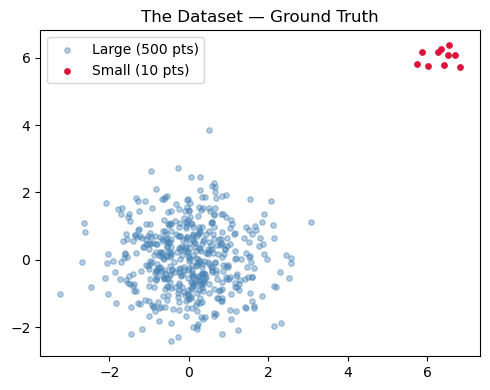

In [5]:
large = np.random.normal(loc=[0, 0], scale=1.0, size=(500, 2))
small = np.random.normal(loc=[6, 6], scale=0.4, size=(10, 2))
X     = np.vstack([large, small])

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(large[:, 0], large[:, 1], s=15, alpha=0.4, color='steelblue', label='Large (500 pts)')
ax.scatter(small[:, 0], small[:, 1], s=15, color='crimson', label='Small (10 pts)')
ax.set_title('The Dataset — Ground Truth')
ax.legend()
plt.tight_layout()
plt.show()

### Generate dendrograms with different three linkage methods


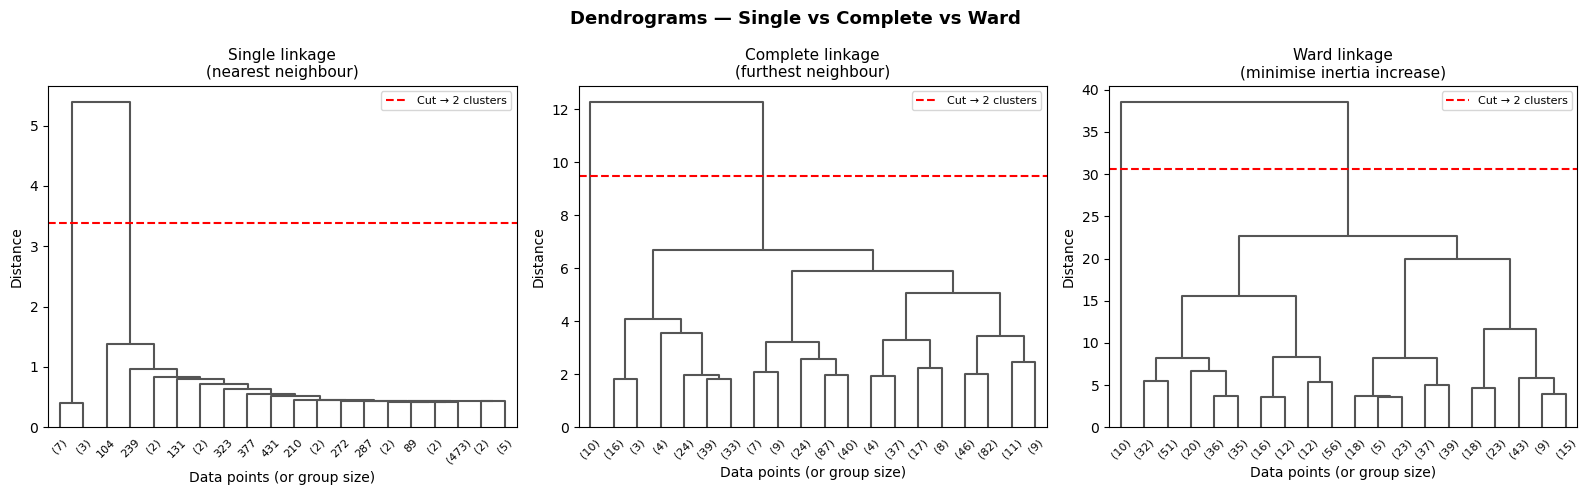

In [6]:
linkage_methods = ['single', 'complete', 'ward']
titles = [
    'Single linkage\n(nearest neighbour)',
    'Complete linkage\n(furthest neighbour)',
    'Ward linkage\n(minimise inertia increase)',
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, method, title in zip(axes, linkage_methods, titles):
    Z = linkage(X, method=method)
    dendrogram(
        Z, ax=ax,
        truncate_mode='lastp',   # show only the last 20 merges for readability
        p=20,
        leaf_rotation=45,
        leaf_font_size=8,
        color_threshold=0,
        above_threshold_color='#555555',
    )
    # mark a cut that yields 2 clusters: midpoint between last and second-to-last merge
    last_merge        = Z[-1, 2]   # height of the final merge (1 cluster)
    second_last_merge = Z[-2, 2]   # height of the second-to-last merge (2 clusters)
    cut = (last_merge + second_last_merge) / 2  # cleanly crosses exactly 2 branches
    ax.axhline(cut, color='red', linestyle='--', linewidth=1.5, label='Cut → 2 clusters')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Data points (or group size)')
    ax.set_ylabel('Distance')
    ax.legend(fontsize=8)

plt.suptitle('Dendrograms — Single vs Complete vs Ward', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Cluster assignments — side-by-side scatter plots

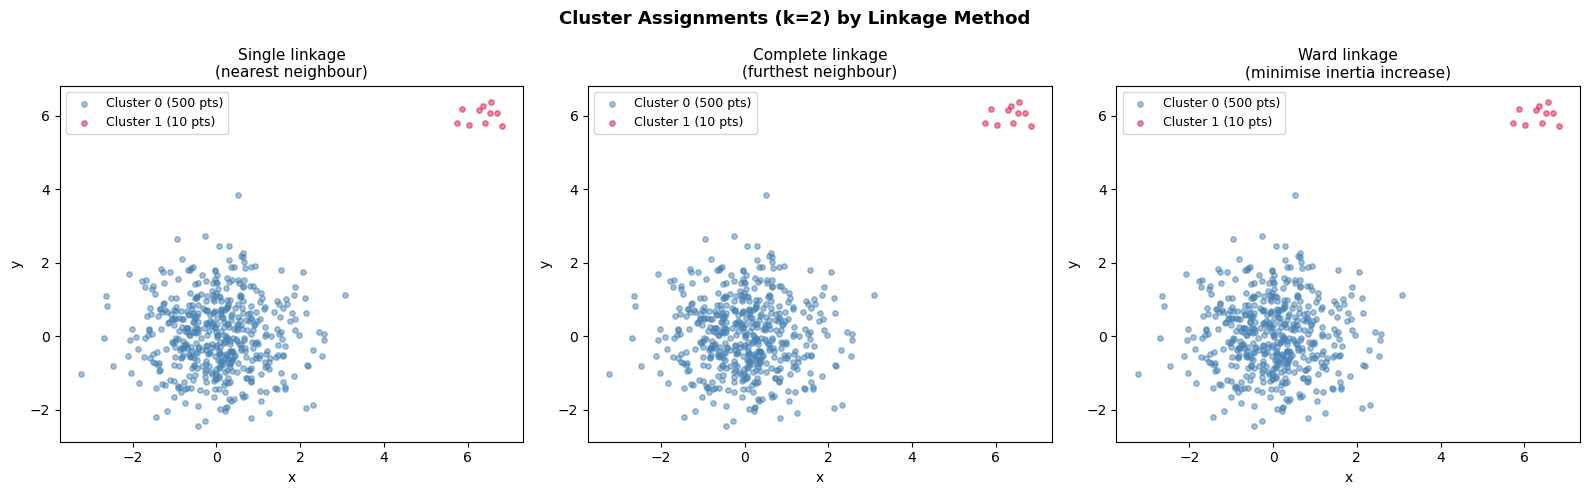

In [7]:
COLORS = ['steelblue', 'crimson']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, method, title in zip(axes, linkage_methods, titles):
    model  = AgglomerativeClustering(n_clusters=2, linkage=method)
    labels = model.fit_predict(X)

    # Ensure the small cluster (points 500-509) is always shown in crimson
    if labels[500] == 0:
        labels = 1 - labels   # flip 0↔1 for consistent color

    counts = [int((labels == k).sum()) for k in range(2)]

    for k in range(2):
        mask = labels == k
        ax.scatter(X[mask, 0], X[mask, 1],
                   s=15, alpha=0.5, color=COLORS[k],
                   label=f'Cluster {k} ({counts[k]} pts)')

    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('Cluster Assignments (k=2) by Linkage Method', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()